# Spike: WSInfer-MIL CAMELYON16 model, attention access and stage-by-stage pipeline

Branch `spike/model` (never merged). Answers the questions in `docs/spike-findings.md`.

**Main question:** can we run segmentation, patching, feature extraction and MIL
**one stage at a time**, with progress inside the long stage, so the web app's
progress bar (REQ-010, D-034, D-036) works as planned? And can we get the
**attention** values for the heatmap (item 7)?

Sections:
1. Setup and versions
2. Model: config, weights hashes, TorchScript code, does `forward()` return attention?
3. Slide: OpenSlide vs tiffslide metadata, microns per pixel
4. Stage 1: tissue segmentation
5. Stage 2: patch coordinates
6. Stage 3: feature extraction with a per-batch progress callback
7. Stage 4: MIL aggregation and attention
8. Stage-by-stage output vs the end-to-end CLI run
9. Can OpenSlide replace tiffslide? (pixels, coordinates, embeddings)
10. DataLoader workers: throughput vs process count
11. Attention heatmap preview
12. Progress-reporting prototype using the `(slide, report)` pipeline shape from D-036
13. Segmentation sensitivity: fixed threshold vs Otsu
14. Summary for `docs/spike-findings.md`

Research demo only. Not for clinical use.

## 1. Setup and versions

In [1]:
import hashlib
import json
import os
import platform
import time
from pathlib import Path

import huggingface_hub
import numpy as np
import openslide
import tiffslide
import torch
import torchvision
import wsinfer_mil
from PIL import Image
from torch.utils.data import DataLoader, Dataset

from wsinfer_mil.client.hfmodel import load_torchscript_model_from_hf
from wsinfer_mil.data import WSIPatches
from wsinfer_mil.extractors import get_extractor_by_name
from wsinfer_mil.patchlib.patch import patch_tissue
from wsinfer_mil.patchlib.segment import _segment_tissue_from_array, segment_tissue

# Same parameters infer_one_slide() passes to segment_tissue().
SEG_PARAMS = dict(
    thumbsize=(2048, 2048),
    median_filter_size=7,
    binary_threshold=7,
    closing_kernel_size=6,
    min_object_size_um2=200**2,
    min_hole_size_um2=190**2,
)

HF_REPO = "kaczmarj/breast-lymph-nodes-metastasis.camelyon16"
HF_REVISION = "507b473a727db6f216902b062d9b677f8a298689"  # pinned
SLIDE = Path(os.environ.get("SPIKE_SLIDE", "../../../slides-staging/test_062.tif")).resolve()
BATCH_SIZE = 64  # same as infer_one_slide()
DEVICE = torch.device("cuda:0")

assert SLIDE.exists(), SLIDE
print("python      ", platform.python_version())
print("torch       ", torch.__version__, "| CUDA runtime", torch.version.cuda, "| cuDNN", torch.backends.cudnn.version())
print("torchvision ", torchvision.__version__)
print("GPU         ", torch.cuda.get_device_name(0), f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB")
print("openslide   ", openslide.__library_version__, "(C) /", openslide.__version__, "(python)")
print("tiffslide   ", tiffslide.__version__)
print("wsinfer-mil ", wsinfer_mil.__version__)
print("slide       ", SLIDE.name, f"{SLIDE.stat().st_size / 2**20:.0f} MiB")

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python       3.12.15
torch        2.14.1+cu132 | CUDA runtime 13.2 | cuDNN 92400
torchvision  0.29.1+cu132
GPU          NVIDIA GeForce RTX 3090 24.0 GiB
openslide    4.0.1 (C) / 1.4.6 (python)
tiffslide    2.5.0
wsinfer-mil  0.1.0
slide        test_062.tif 455 MiB


## 2. Model

`load_torchscript_model_from_hf` downloads `torchscript_model.pt` and `config.json`
at the pinned revision (cached under `~/.cache/huggingface`; no network after the first run).
We record SHA-256 values for the future `models/manifest.json` (REQ-016).

In [2]:
def sha256(path, chunk=2**20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while b := f.read(chunk):
            h.update(b)
    return h.hexdigest()

mil = load_torchscript_model_from_hf(HF_REPO, HF_REVISION)
print("config:", mil.config)

Extractor = get_extractor_by_name(mil.config.feature_extractor)
extractor = Extractor()
encoder = extractor.model  # cached_property: downloads + loads CTransPath TorchScript onto the GPU

# wsinfer-mil downloads CTransPath WITHOUT a pinned revision; resolve the same file to hash it.
encoder_path = Path(huggingface_hub.hf_hub_download(repo_id="kaczmarj/CTransPath", filename="torchscript_model.pt"))
for name, p in [("MIL model", Path(mil.model_path)), ("CTransPath encoder", encoder_path)]:
    print(f"{name:20s} {p.stat().st_size / 2**20:7.1f} MiB  sha256={sha256(p)}")
    print(f"{'':20s} {p}")
print("encoder transform:", extractor.transform)

config: ModelConfiguration(num_classes=2, class_names=['no-metastasis', 'metastasis'], feature_extractor='ctranspath', patch_size_um=128)


/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


MIL model                1.3 MiB  sha256=b3e58653c39af79b5d2111ca1661c2c7e9bd12656ef8a11f1319a8aceaddac9c
                     /home/benjaminrbremer/.cache/huggingface/hub/models--kaczmarj--breast-lymph-nodes-metastasis.camelyon16/snapshots/507b473a727db6f216902b062d9b677f8a298689/torchscript_model.pt
CTransPath encoder     106.2 MiB  sha256=8c5e08e059f553087e124aea270dcb8daf147f7b2bc88624725bef68c7335fe2
                     /home/benjaminrbremer/.cache/huggingface/hub/models--kaczmarj--CTransPath/snapshots/d426c122c59cf1db044745ceebdf775064020a89/torchscript_model.pt
encoder transform: Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


### TorchScript code of the MIL model

`model.code` is the TorchScript source of `forward()`. Two questions:
does it return attention, and is that attention already softmax-normalised?

In [3]:
model = torch.jit.load(mil.model_path, map_location="cpu")
# GOTCHA: the TorchScript file was saved in training mode and wsinfer-mil never calls
# .eval(), so its dropout(0.25) layers are active at inference -> random outputs.
print("training flag as loaded:", model.training)
with torch.inference_mode():
    _bag = torch.randn(500, 768, generator=torch.Generator().manual_seed(0))
    print("train mode, 3 runs:", [round(float(model(_bag)[0].softmax(1)[0, 1]), 5) for _ in range(3)])
    model.eval()
    print("eval mode,  3 runs:", [round(float(model(_bag)[0].softmax(1)[0, 1]), 5) for _ in range(3)])
print(model.code)

training flag as loaded: True
train mode, 3 runs: [0.99745, 0.99661, 0.99796]
eval mode,  3 runs: [0.99753, 0.99753, 0.99753]
def forward(self,
    H: Tensor) -> __torch__.AttentionMILModelOutput:
  _0 = "Expected H to have 2 dimensions but got {}"
  if torch.eq(torch.dim(H), 2):
    pass
  else:
    _1 = torch.add("AssertionError: ", torch.format(_0, torch.dim(H)))
    ops.prim.RaiseException(_1)
  encoder = self.encoder
  H0 = (encoder).forward(H, )
  attention_weights = self.attention_weights
  A = (attention_weights).forward(H0, )
  A0 = torch.transpose(A, 1, 0)
  A1 = __torch__.torch.nn.functional.softmax(A0, 1, 3, None, )
  M = torch.mm(A1, H0)
  head = self.head
  logits = (head).forward(M, )
  _2 = __torch__.AttentionMILModelOutput(logits, A)
  return _2



In [4]:
# Submodules and parameter shapes. This is enough to re-implement ABMIL from
# state_dict() if we ever have to.
for name, mod in model.named_children():
    print(f"{name:20s} {mod.original_name}")
print()
for k, v in model.state_dict().items():
    print(f"{k:45s} {tuple(v.shape)}")
print("total params:", sum(v.numel() for v in model.state_dict().values()))

encoder              Sequential
attention_weights    GatedAttentionLayer
head                 Linear

encoder.0.weight                              (256, 768)
encoder.0.bias                                (256,)
attention_weights.attention_V.0.weight        (256, 256)
attention_weights.attention_V.0.bias          (256,)
attention_weights.attention_U.0.weight        (256, 256)
attention_weights.attention_U.0.bias          (256,)
attention_weights.attention_weights.weight    (1, 256)
attention_weights.attention_weights.bias      (1,)
head.weight                                   (2, 256)
head.bias                                     (2,)
total params: 329219


In [5]:
# Code of the attention submodule(s), whichever names the model uses.
for name, mod in model.named_modules():
    if name and "attention" in name.lower() and hasattr(mod, "code"):
        print(f"--- {name} ---")
        print(mod.code)

--- attention_weights ---
def forward(self,
    H: Tensor) -> Tensor:
  attention_V = self.attention_V
  A_V = (attention_V).forward(H, )
  attention_U = self.attention_U
  A_U = (attention_U).forward(H, )
  attention_weights = self.attention_weights
  A = (attention_weights).forward(torch.mul(A_V, A_U), )
  return A

--- attention_weights.attention_V ---
def forward(self,
    input: Tensor) -> Tensor:
  _0 = getattr(self, "0")
  _1 = getattr(self, "1")
  _2 = getattr(self, "2")
  input0 = (_0).forward(input, )
  input1 = (_1).forward(input0, )
  return (_2).forward(input1, )

--- attention_weights.attention_V.0 ---
def forward(self,
    input: Tensor) -> Tensor:
  weight = self.weight
  bias = self.bias
  return torch.linear(input, weight, bias)

--- attention_weights.attention_V.1 ---
def forward(self,
    input: Tensor) -> Tensor:
  return torch.tanh(input)

--- attention_weights.attention_V.2 ---
def forward(self,
    input: Tensor) -> Tensor:
  training = self.training
  _0 = __to

## 3. Slide: metadata through OpenSlide and tiffslide

Only allowlisted properties are printed (PHI rule: we never touch `associated_images`).

In [6]:
oslide = openslide.OpenSlide(SLIDE)
tslide = tiffslide.TiffSlide(SLIDE)

print("OpenSlide  vendor:", oslide.properties.get(openslide.PROPERTY_NAME_VENDOR))
print("OpenSlide  mpp-x/y:", oslide.properties.get(openslide.PROPERTY_NAME_MPP_X), oslide.properties.get(openslide.PROPERTY_NAME_MPP_Y))
print("OpenSlide  objective-power:", oslide.properties.get(openslide.PROPERTY_NAME_OBJECTIVE_POWER))
print("OpenSlide  dimensions:", oslide.dimensions, "levels:", oslide.level_count)
print("OpenSlide  level downsamples:", [round(d, 3) for d in oslide.level_downsamples])
print()
print("tiffslide  mpp-x/y:", tslide.properties["tiffslide.mpp-x"], tslide.properties["tiffslide.mpp-y"])
print("tiffslide  dimensions:", tslide.dimensions, "levels:", tslide.level_count)
print("tiffslide  level downsamples:", [round(d, 3) for d in tslide.level_downsamples])
print()
print("same dimensions:", oslide.dimensions == tslide.dimensions)
print("same level dims:", tuple(oslide.level_dimensions) == tuple(tslide.level_dimensions))

MPP = (float(tslide.properties["tiffslide.mpp-x"]) + float(tslide.properties["tiffslide.mpp-y"])) / 2
PATCH_PX = round(mil.config.patch_size_um / MPP)
print(f"\navg mpp = {MPP:.5f} um/px  ->  {mil.config.patch_size_um} um patch = {PATCH_PX} px at level 0")

OpenSlide  vendor: philips
OpenSlide  mpp-x/y: 0.22632099999999999 0.22631600000000002
OpenSlide  objective-power: None
OpenSlide  dimensions: (135168, 28672) levels: 10
OpenSlide  level downsamples: [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]

tiffslide  mpp-x/y: 0.226321 0.22631600000000002
tiffslide  dimensions: (135168, 28672) levels: 10
tiffslide  level downsamples: [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]

same dimensions: True
same level dims: True

avg mpp = 0.22632 um/px  ->  128 um patch = 566 px at level 0


## 4. Stage 1: tissue segmentation

WSInfer-MIL takes a 2048 px thumbnail, uses the HSV **saturation** channel,
applies a median blur and a fixed threshold (7), runs morphological closing,
and then removes small objects and holes (sizes are in µm², so they don't depend
on the slide's resolution).

In [7]:
timings = {}

t0 = time.perf_counter()
mask = segment_tissue(tslide, **SEG_PARAMS)
timings["segment"] = time.perf_counter() - t0

tissue_fraction = mask.mean()
mask_px_area_um2 = (MPP * tslide.dimensions[0] / mask.shape[1]) * (MPP * tslide.dimensions[1] / mask.shape[0])
tissue_area_mm2 = mask.sum() * mask_px_area_um2 / 1e6
print(f"segment: {timings['segment']:.2f} s, mask {mask.shape}, tissue fraction {tissue_fraction:.3f}, "
      f"tissue area {tissue_area_mm2:.1f} mm^2")

segment: 0.14 s, mask (434, 2048), tissue fraction 0.962, tissue area 190.9 mm^2


/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

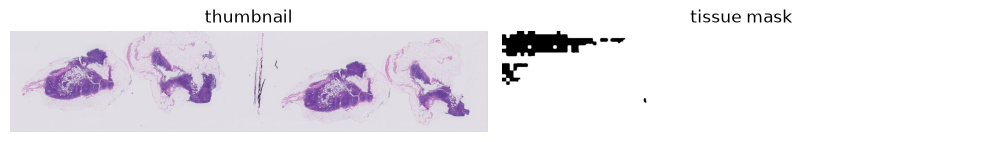

In [8]:
import matplotlib.pyplot as plt

thumb = tslide.get_thumbnail((1024, 1024))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(thumb); ax[0].set_title("thumbnail"); ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("tissue mask"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 5. Stage 2: patch coordinates

In [9]:
t0 = time.perf_counter()
coords = patch_tissue(tslide, binary_tissue_mask=mask, patch_size_um=mil.config.patch_size_um)
timings["patch"] = time.perf_counter() - t0
print(f"patch: {timings['patch']:.2f} s, coords {coords.shape} (minx, miny, w, h at level 0), dtype {coords.dtype}")
print(coords[:3])
N = len(coords)
print("patches:", N, "-> batches of", BATCH_SIZE, "=", -(-N // BATCH_SIZE))

patch: 0.09 s, coords (11728, 4) (minx, miny, w, h at level 0), dtype int64
[[   0    0  566  566]
 [   0  566  566  566]
 [   0 3962  566  566]]
patches: 11728 -> batches of 64 = 184


## 6. Stage 3: feature extraction with a per-batch progress callback

`PatchFeatureExtractor.get_embeddings()` contains a tqdm loop and gives no
callback. We write the same loop ourselves (identical logic: `inference_mode`,
`.to(device)`, concatenate) and call `report(done, total)` after every batch.
This is the hook the job worker needs for patch-count progress.

In [10]:
def embed(loader, encoder, report=None):
    total = len(loader.dataset)
    done = 0
    out = []
    with torch.inference_mode():
        for batch in loader:
            e = encoder(batch.to(DEVICE, non_blocking=True)).detach().cpu().numpy()
            out.append(e)
            done += len(batch)
            if report:
                report(done, total)
    return np.concatenate(out)

def make_loader(dataset, num_workers):
    if num_workers == 0:
        dataset.worker_init()  # same workaround as infer_one_slide()
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers,
                      worker_init_fn=dataset.worker_init, pin_memory=True)

progress_events = []
def record(done, total):
    progress_events.append((time.perf_counter(), done, total))

NUM_WORKERS = 8
ds = WSIPatches(wsi_path=SLIDE, patch_coordindates=coords, transform=extractor.transform)
torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
t0 = time.perf_counter()
embedding = embed(make_loader(ds, NUM_WORKERS), encoder, report=record)
timings["features"] = time.perf_counter() - t0
peak_mem_features = torch.cuda.max_memory_allocated() / 2**30

print(f"features: {timings['features']:.1f} s ({N / timings['features']:.0f} patches/s, num_workers={NUM_WORKERS}), "
      f"embedding {embedding.shape} {embedding.dtype}, peak torch GPU mem {peak_mem_features:.2f} GiB")
print("progress callbacks:", len(progress_events), "| first:", progress_events[0][1:], "| last:", progress_events[-1][1:])
gaps = np.diff([t0] + [t for t, *_ in progress_events])
print(f"time between callbacks: median {np.median(gaps)*1000:.0f} ms, max {gaps.max()*1000:.0f} ms (first batch includes worker start-up)")

features: 23.4 s (500 patches/s, num_workers=8), embedding (11728, 768) float32, peak torch GPU mem 0.79 GiB
progress callbacks: 184 | first: (64, 11728) | last: (11728, 11728)
time between callbacks: median 79 ms, max 3530 ms (first batch includes worker start-up)


## 7. Stage 4: MIL aggregation and attention

`forward(embedding)` takes the whole bag `(N, 768)` at once.

In [11]:
emb_t = torch.from_numpy(embedding)

t0 = time.perf_counter()
with torch.inference_mode():
    logits, attention = model(emb_t)
timings["mil"] = time.perf_counter() - t0

probs = logits.softmax(1).numpy()
attention = attention.numpy()
print(f"mil (CPU): {timings['mil']*1000:.0f} ms")
print("logits", tuple(logits.shape), logits.numpy().round(4))
print("probs ", dict(zip(mil.config.class_names, probs[0].round(6))))
print("attention shape", attention.shape, attention.dtype)
a = attention.squeeze()
print(f"attention min {a.min():.3e}  max {a.max():.3e}  mean {a.mean():.3e}  sum {a.sum():.4f}")
print(f"1/N = {1/len(a):.3e}  max/mean = {a.max()/a.mean():.1f}")
print("percentiles 1/50/99/99.9:", np.percentile(a, [1, 50, 99, 99.9]))

mil (CPU): 39 ms
logits (1, 2) [[ 1.0002 -0.6366]]
probs  {'no-metastasis': np.float32(0.837096), 'metastasis': np.float32(0.162904)}
attention shape (11728, 1) float32
attention min -8.433e+00  max -1.247e+00  mean -5.026e+00  sum -58947.0938
1/N = 8.527e-05  max/mean = 0.2
percentiles 1/50/99/99.9: [-7.81318635 -4.74509239 -3.53728585 -3.03840768]


In [12]:
# Is the returned attention already softmax-normalised (sums to 1), or raw scores?
# And does the GPU give the same answer?
model_gpu = torch.jit.load(mil.model_path, map_location=DEVICE).eval()
with torch.inference_mode():
    lg, at = model_gpu(emb_t.to(DEVICE))
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    lg, at = model_gpu(emb_t.to(DEVICE)); torch.cuda.synchronize()
    t_gpu = time.perf_counter() - t0
print(f"mil (GPU, warm): {t_gpu*1000:.1f} ms")
print("GPU vs CPU max |dprob|:", float(np.abs(lg.softmax(1).cpu().numpy() - probs).max()))
print("GPU vs CPU max |dattn|:", float(np.abs(at.cpu().numpy() - attention).max()))
print("attention sums to 1:", np.isclose(a.sum(), 1.0, atol=1e-4))

mil (GPU, warm): 9.1 ms
GPU vs CPU max |dprob|: 5.960464477539063e-08
GPU vs CPU max |dattn|: 1.9073486328125e-06
attention sums to 1: False


/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


## 8. Stage-by-stage output vs the end-to-end CLI run

The CLI run (`wsinfer-mil run ...` on this slide) gave **no-metastasis 0.834961 /
metastasis 0.165039** and stored its tissue mask, patches and embedding in the
wsinfer-mil cache. Identical coordinates and embeddings prove that calling the stages
one at a time is equivalent to `infer_one_slide()`. The probability differs slightly
because the CLI runs the MIL model with dropout on (section 2); ours uses `.eval()`.

In [13]:
from wsinfer_mil.cache import Cache
from wsinfer_mil.quickhash import quickhash

cache = Cache(slide_path=SLIDE, slide_quickhash=quickhash(tslide), patch_size_um=mil.config.patch_size_um)
cli_coords = cache.get_patch_coordinates()
cli_emb = cache.get_embedding(extractor)
print("cache dir name:", cache.slide_cache_dir.name, " <- note: derived from the file NAME")
print("coords identical to CLI:", cli_coords is not None and np.array_equal(cli_coords, coords))
print("embedding max |diff| vs CLI:", None if cli_emb is None else float(np.abs(cli_emb - embedding).max()))
print("metastasis prob (stage-by-stage):", round(float(probs[0, 1]), 6), " CLI: 0.165039")

cache dir name: test_062.tif_md5-ab76734f95ad06193625cd762dfc7d33  <- note: derived from the file NAME
coords identical to CLI: True


embedding max |diff| vs CLI: 0.0
metastasis prob (stage-by-stage): 0.162904  CLI: 0.165039


## 9. Can OpenSlide replace tiffslide?

The service already uses OpenSlide for the registry and tiles (D-025). If the
pipeline can use OpenSlide too, we have one slide reader instead of two
(less SOUP, one set of coordinates). Three checks:
1. segmentation from an OpenSlide thumbnail vs a tiffslide thumbnail
2. patch coordinates (`patch_tissue` only needs `.dimensions` and the mpp properties)
3. pixels and embeddings from `read_region` at level 0

In [14]:
# 1. Segmentation from an OpenSlide thumbnail, using the same array-level function.
o_thumb = np.asarray(oslide.get_thumbnail(SEG_PARAMS["thumbsize"]).convert("RGB"))
t_thumb = np.asarray(tslide.get_thumbnail(SEG_PARAMS["thumbsize"]).convert("RGB"))
print("thumbnail sizes  openslide", o_thumb.shape, " tiffslide", t_thumb.shape)

def seg_from_thumb(arr, slide_dims):
    thumb_mpp = (MPP * (np.array(slide_dims) / np.array([arr.shape[1], arr.shape[0]]))).mean()
    return _segment_tissue_from_array(
        arr, median_filter_size=SEG_PARAMS["median_filter_size"], binary_threshold=SEG_PARAMS["binary_threshold"],
        closing_kernel_size=SEG_PARAMS["closing_kernel_size"],
        min_object_size_px=round(SEG_PARAMS["min_object_size_um2"] / thumb_mpp**2),
        min_hole_size_px=round(SEG_PARAMS["min_hole_size_um2"] / thumb_mpp**2))

o_mask = seg_from_thumb(o_thumb, oslide.dimensions)
if o_mask.shape == mask.shape:
    iou = (o_mask & mask).sum() / (o_mask | mask).sum()
    print(f"mask IoU openslide vs tiffslide: {iou:.4f}  (identical: {np.array_equal(o_mask, mask)})")
else:
    print("mask shapes differ:", o_mask.shape, mask.shape)

thumbnail sizes  openslide (434, 2048, 3)  tiffslide (434, 2048, 3)
mask IoU openslide vs tiffslide: 1.0000  (identical: True)


/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

In [15]:
# 2. Patch coordinates from an OpenSlide-backed shim (only .dimensions + mpp properties are used).
class OpenSlideShim:
    def __init__(self, s):
        self.dimensions = s.dimensions
        self.properties = {"tiffslide.mpp-x": float(s.properties[openslide.PROPERTY_NAME_MPP_X]),
                           "tiffslide.mpp-y": float(s.properties[openslide.PROPERTY_NAME_MPP_Y])}

o_coords = patch_tissue(OpenSlideShim(oslide), binary_tissue_mask=o_mask, patch_size_um=mil.config.patch_size_um)
print("patches openslide", len(o_coords), " tiffslide", len(coords),
      " identical:", np.array_equal(o_coords, coords))

patches openslide 11728  tiffslide 11728  identical: True


In [16]:
# 3. Pixels and embeddings from OpenSlide read_region at level 0.
class OpenSlidePatches(Dataset):
    def __init__(self, path, coords, transform):
        self.path, self.coords, self.transform = path, coords, transform
    def worker_init(self, worker_id=None):
        self.slide = openslide.OpenSlide(self.path)
    def __len__(self):
        return len(self.coords)
    def __getitem__(self, i):
        x, y, w, h = (int(v) for v in self.coords[i])
        # OpenSlide returns RGBA; convert("RGB") matches what WSIPatches does.
        return self.transform(self.slide.read_region((x, y), 0, (w, h)).convert("RGB"))

rng = np.random.default_rng(0)
idx = np.sort(rng.choice(len(coords), size=512, replace=False))
max_px_diff = 0
for i in idx[:100]:
    x, y, w, h = (int(v) for v in coords[i])
    po = np.asarray(oslide.read_region((x, y), 0, (w, h)).convert("RGB"), dtype=np.int16)
    pt = np.asarray(tslide.read_region((x, y), 0, (w, h)).convert("RGB"), dtype=np.int16)
    max_px_diff = max(max_px_diff, int(np.abs(po - pt).max()))
print("max pixel |diff| over 100 patches (0-255):", max_px_diff)

o_ds = OpenSlidePatches(SLIDE, coords[idx], extractor.transform)
o_emb = embed(make_loader(o_ds, 4), encoder)
print("embedding max |diff| over 512 patches:", float(np.abs(o_emb - embedding[idx]).max()))

# Swap these 512 OpenSlide embeddings into the bag and re-run MIL.
mixed = embedding.copy(); mixed[idx] = o_emb
with torch.inference_mode():
    p_mixed = model(torch.from_numpy(mixed))[0].softmax(1).numpy()
print("metastasis prob with 512 OpenSlide embeddings swapped in:", round(float(p_mixed[0, 1]), 6))

max pixel |diff| over 100 patches (0-255): 0


embedding max |diff| over 512 patches: 5.960464477539063e-08
metastasis prob with 512 OpenSlide embeddings swapped in: 0.162904


## 10. DataLoader workers vs throughput

The CLI defaults to one worker **process** per core (16 here). In the service,
feature extraction runs inside one worker *thread* of the FastAPI process (D-005), so
we need to know how much the process count matters. Timed on the first 3,200 patches.

In [17]:
sub = coords[:3200]
results = {}
for nw in [0, 2, 4, 8, 16]:
    ds_sub = WSIPatches(wsi_path=SLIDE, patch_coordindates=sub, transform=extractor.transform)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    embed(make_loader(ds_sub, nw), encoder)
    torch.cuda.synchronize(); dt = time.perf_counter() - t0
    results[nw] = len(sub) / dt
    print(f"num_workers={nw:2d}: {dt:6.1f} s  {results[nw]:6.0f} patches/s")

num_workers= 0:   39.1 s      82 patches/s


num_workers= 2:   17.7 s     181 patches/s


num_workers= 4:   10.4 s     308 patches/s


num_workers= 8:    6.6 s     486 patches/s


num_workers=16:    6.3 s     511 patches/s


## 11. Attention heatmap preview

A quick look ahead to item 7 (D-010): place each patch's attention on a grid with
one cell per 128 µm patch, then normalise by percentiles. Section 7 showed the model
returns the **raw pre-softmax score** `A` (softmax happens inside `forward()`), so
these are log-scale values; percentile normalisation works on them directly, and
softmax would not change the ranking.

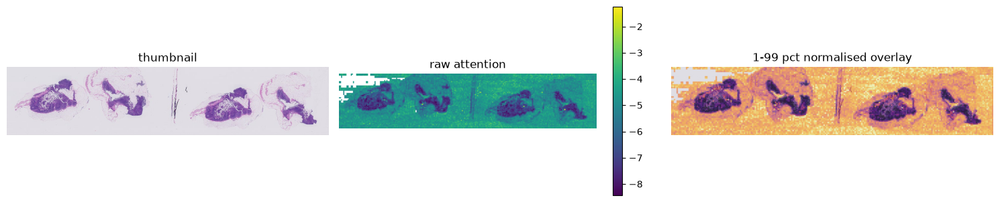

grid (51, 239) | patch coords are on an exact PATCH_PX grid: True


In [18]:
grid_w = -(-tslide.dimensions[0] // PATCH_PX)
grid_h = -(-tslide.dimensions[1] // PATCH_PX)
heat = np.full((grid_h, grid_w), np.nan, dtype=np.float32)
gx = coords[:, 0] // PATCH_PX
gy = coords[:, 1] // PATCH_PX
heat[gy, gx] = a

lo, hi = np.percentile(a, [1, 99])
heat_norm = np.clip((heat - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(thumb); ax[0].set_title("thumbnail"); ax[0].axis("off")
im = ax[1].imshow(heat, cmap="viridis"); ax[1].set_title("raw attention"); ax[1].axis("off"); fig.colorbar(im, ax=ax[1], shrink=0.6)
ax[2].imshow(thumb, extent=(0, grid_w, grid_h, 0))
ax[2].imshow(heat_norm, cmap="inferno", alpha=0.6, extent=(0, grid_w, grid_h, 0)); ax[2].set_title("1-99 pct normalised overlay"); ax[2].axis("off")
plt.tight_layout(); plt.show()
print("grid", heat.shape, "| patch coords are on an exact PATCH_PX grid:", bool(((coords[:, :2] - PATCH_PX // 2 + round(PATCH_PX / 2)) % PATCH_PX == 0).all()))

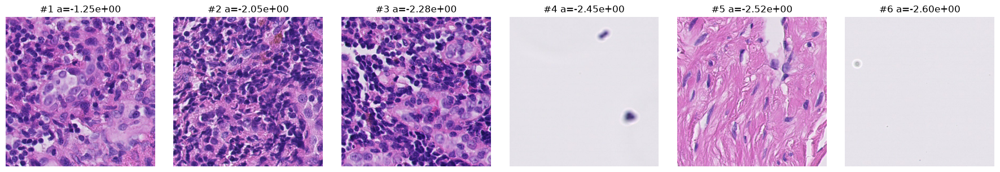

In [19]:
# Highest-attention patches, for a visual sanity check.
top = np.argsort(a)[::-1][:6]
fig, ax = plt.subplots(1, 6, figsize=(18, 3))
for k, i in enumerate(top):
    x, y, w, h = (int(v) for v in coords[i])
    ax[k].imshow(oslide.read_region((x, y), 0, (w, h)).convert("RGB")); ax[k].axis("off")
    ax[k].set_title(f"#{k+1} a={a[i]:.2e}")
plt.tight_layout(); plt.show()

## 12. Progress-reporting prototype using the D-036 pipeline shape

The item 6 pipeline is a callable `(slide_row, report) -> PipelineResult`. Here is
the same idea in a few lines, using the stages above, to show that the progress
events the web app expects can be produced. `report(stage, done, total)` is
called at each stage boundary and after every feature batch.

In [20]:
def run_pipeline(path, report):
    ts = tiffslide.TiffSlide(path)
    report("segmenting", 0, 1)
    m = segment_tissue(ts, **SEG_PARAMS)
    report("patching", 0, 1)
    c = patch_tissue(ts, binary_tissue_mask=m, patch_size_um=mil.config.patch_size_um)
    report("extracting_features", 0, len(c))
    d = WSIPatches(wsi_path=path, patch_coordindates=c, transform=extractor.transform)
    e = embed(make_loader(d, NUM_WORKERS), encoder, report=lambda done, tot: report("extracting_features", done, tot))
    report("aggregating", 0, 1)
    with torch.inference_mode():
        lg, at = model(torch.from_numpy(e))
    report("done", 1, 1)
    return lg.softmax(1).numpy()[0], at.numpy().squeeze(), c

events = []
t_start = time.perf_counter()
def report(stage, done, total):
    events.append((round(time.perf_counter() - t_start, 2), stage, done, total))

torch.cuda.reset_peak_memory_stats()
p, att, c = run_pipeline(SLIDE, report)
total_time = time.perf_counter() - t_start
peak_total = torch.cuda.max_memory_allocated() / 2**30

stage_start = {}
for t, s, *_ in events:
    stage_start.setdefault(s, t)
print(f"total {total_time:.1f} s, peak torch GPU mem {peak_total:.2f} GiB, {len(events)} report() calls")
for s, t in stage_start.items():
    print(f"  {s:22s} starts at {t:6.2f} s")
print("first events:", events[:4])
print("last events: ", events[-3:])
print("same result as before:", np.allclose(p, probs[0], atol=1e-6), np.allclose(att, a, atol=1e-7))

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

total 23.4 s, peak torch GPU mem 0.80 GiB, 189 report() calls
  segmenting             starts at   0.00 s
  patching               starts at   0.10 s
  extracting_features    starts at   0.16 s
  aggregating            starts at  23.39 s
  done                   starts at  23.42 s
first events: [(0.0, 'segmenting', 0, 1), (0.1, 'patching', 0, 1), (0.16, 'extracting_features', 0, 11728), (1.35, 'extracting_features', 64, 11728)]
last events:  [(23.33, 'extracting_features', 11728, 11728), (23.39, 'aggregating', 0, 1), (23.42, 'done', 1, 1)]
same result as before: True True


## 13. Segmentation sensitivity: the fixed saturation threshold

The section 4 mask covers about 96% of this slide. The Philips scans have a lavender
background with HSV saturation of about 8, just above wsinfer-mil's fixed
`binary_threshold=7`, so most of the glass counts as tissue. The section 11
heatmap shows the result: background patches get *higher* attention than most tissue.

Below we compare a per-slide **Otsu** threshold on the same blurred saturation
channel, with all other parameters unchanged. The patch grid is global (every
566 px from the slide origin), so Otsu patches are a subset of the default patches
and we can reuse their embeddings without re-running CTransPath.

In [21]:
import cv2 as cv
from skimage.filters import threshold_otsu

def blurred_saturation(thumb_rgb):
    return cv.medianBlur(cv.cvtColor(thumb_rgb, cv.COLOR_RGB2HSV)[:, :, 1], SEG_PARAMS["median_filter_size"])

def seg_with_threshold(arr, slide_dims, threshold):
    thumb_mpp = (MPP * (np.array(slide_dims) / np.array([arr.shape[1], arr.shape[0]]))).mean()
    return _segment_tissue_from_array(
        arr, median_filter_size=SEG_PARAMS["median_filter_size"], binary_threshold=threshold,
        closing_kernel_size=SEG_PARAMS["closing_kernel_size"],
        min_object_size_px=round(SEG_PARAMS["min_object_size_um2"] / thumb_mpp**2),
        min_hole_size_px=round(SEG_PARAMS["min_hole_size_um2"] / thumb_mpp**2))

otsu_t = int(threshold_otsu(blurred_saturation(o_thumb)))
otsu_mask = seg_with_threshold(o_thumb, oslide.dimensions, otsu_t)
otsu_coords = patch_tissue(OpenSlideShim(oslide), binary_tissue_mask=otsu_mask, patch_size_um=mil.config.patch_size_um)

# Reuse embeddings: look up each Otsu patch in the default patch set.
row_of = {(int(x), int(y)): i for i, (x, y, _, _) in enumerate(coords)}
sel = np.array([row_of[(int(x), int(y))] for x, y, _, _ in otsu_coords])
with torch.inference_mode():
    lg_o, at_o = model(torch.from_numpy(embedding[sel]))
p_otsu = lg_o.softmax(1).numpy()[0]
a_otsu = at_o.numpy().squeeze()

print(f"Otsu threshold: {otsu_t} (default 7)")
print(f"{'':10s} {'tissue frac':>11s} {'patches':>8s} {'P(metastasis)':>14s}")
print(f"{'default':10s} {mask.mean():11.3f} {len(coords):8d} {probs[0, 1]:14.6f}")
print(f"{'otsu':10s} {otsu_mask.mean():11.3f} {len(otsu_coords):8d} {p_otsu[1]:14.6f}")

# Fixed threshold 20 (the recommendation after the mask comparison below).
mask20 = seg_with_threshold(o_thumb, oslide.dimensions, 20)
coords20 = patch_tissue(OpenSlideShim(oslide), binary_tissue_mask=mask20, patch_size_um=mil.config.patch_size_um)
sel20 = np.array([row_of[(int(x), int(y))] for x, y, _, _ in coords20])
with torch.inference_mode():
    lg_20, at_20 = model(torch.from_numpy(embedding[sel20]))
p_20 = lg_20.softmax(1).numpy()[0]
a_20 = at_20.numpy().squeeze()
area20_mm2 = mask20.sum() * mask_px_area_um2 / 1e6
print(f"{'fixed 20':10s} {mask20.mean():11.3f} {len(coords20):8d} {p_20[1]:14.6f}")
print(f"tissue area: default {tissue_area_mm2:.1f} mm^2, otsu {otsu_mask.sum() * mask_px_area_um2 / 1e6:.1f} mm^2, fixed 20 {area20_mm2:.1f} mm^2")

Otsu threshold: 60 (default 7)
           tissue frac  patches  P(metastasis)
default          0.962    11728       0.162904
otsu             0.124     1435       0.218303


/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

fixed 20         0.189     2226       0.134893
tissue area: default 190.9 mm^2, otsu 24.5 mm^2, fixed 20 37.5 mm^2


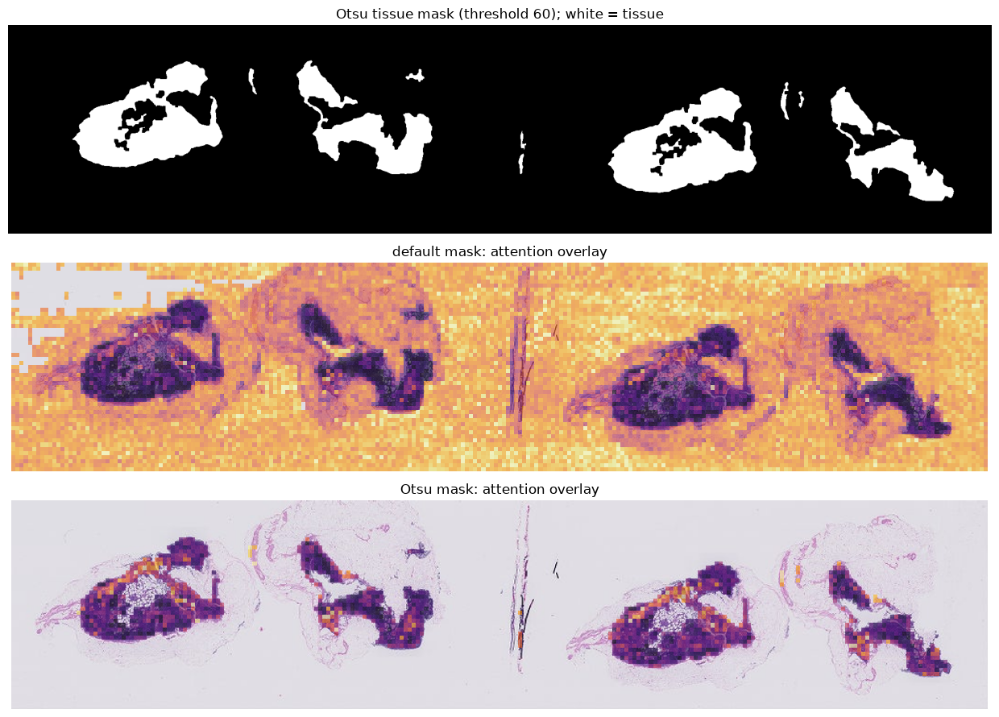

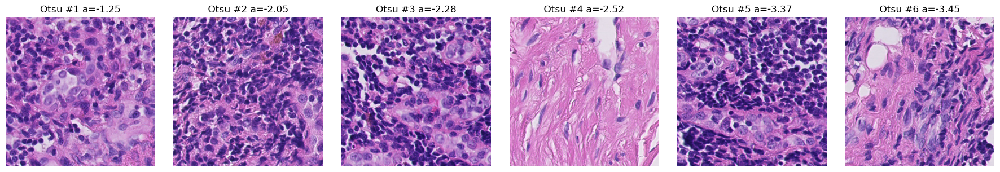

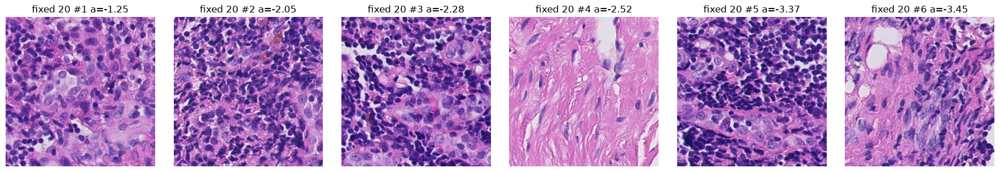

In [22]:
heat_o = np.full((grid_h, grid_w), np.nan, dtype=np.float32)
heat_o[otsu_coords[:, 1] // PATCH_PX, otsu_coords[:, 0] // PATCH_PX] = a_otsu
lo_o, hi_o = np.percentile(a_otsu, [1, 99])

fig, ax = plt.subplots(3, 1, figsize=(14, 9))
ax[0].imshow(otsu_mask, cmap="gray"); ax[0].set_title(f"Otsu tissue mask (threshold {otsu_t}); white = tissue")
ax[1].imshow(thumb, extent=(0, grid_w, grid_h, 0))
ax[1].imshow(heat_norm, cmap="inferno", alpha=0.6, extent=(0, grid_w, grid_h, 0)); ax[1].set_title("default mask: attention overlay")
ax[2].imshow(thumb, extent=(0, grid_w, grid_h, 0))
ax[2].imshow(np.clip((heat_o - lo_o) / (hi_o - lo_o), 0, 1), cmap="inferno", alpha=0.6, extent=(0, grid_w, grid_h, 0))
ax[2].set_title("Otsu mask: attention overlay")
for x in ax: x.axis("off")
plt.tight_layout(); plt.show()

top_o = np.argsort(a_otsu)[::-1][:6]
fig, ax = plt.subplots(1, 6, figsize=(18, 3))
for k, i in enumerate(top_o):
    x, y, w, h = (int(v) for v in otsu_coords[i])
    ax[k].imshow(oslide.read_region((x, y), 0, (w, h)).convert("RGB")); ax[k].axis("off")
    ax[k].set_title(f"Otsu #{k+1} a={a_otsu[i]:.2f}")
plt.tight_layout(); plt.show()

top_20 = np.argsort(a_20)[::-1][:6]
fig, ax = plt.subplots(1, 6, figsize=(18, 3))
for k, i in enumerate(top_20):
    x, y, w, h = (int(v) for v in coords20[i])
    ax[k].imshow(oslide.read_region((x, y), 0, (w, h)).convert("RGB")); ax[k].axis("off")
    ax[k].set_title(f"fixed 20 #{k+1} a={a_20[i]:.2f}")
plt.tight_layout(); plt.show()

In [23]:
# How common is this? Background saturation and tissue fraction on every staged slide.
print(f"{'slide':10s} {'vendor':8s} {'sat p25':>7s} {'otsu':>5s} {'frac@7':>7s} {'frac@otsu':>9s}")
for f in sorted(SLIDE.parent.glob("test_*.tif")):
    s = openslide.OpenSlide(f)
    th = np.asarray(s.get_thumbnail(SEG_PARAMS["thumbsize"]).convert("RGB"))
    sat = blurred_saturation(th)
    t = int(threshold_otsu(sat))
    print(f"{f.stem:10s} {s.properties.get(openslide.PROPERTY_NAME_VENDOR):8s} {int(np.percentile(sat, 25)):7d} {t:5d} "
          f"{(sat > 7).mean():7.3f} {(sat > t).mean():9.3f}")

slide      vendor   sat p25  otsu  frac@7 frac@otsu


test_001   philips        7    63   0.651     0.155
test_062   philips        8    60   0.950     0.121


test_065   philips        2    38   0.240     0.060


test_128   philips        8    58   0.989     0.134


### What does Otsu remove that a threshold of 20 keeps?

Thresholds of about 15–20 already remove the lavender background (saturation of about 8).
Otsu lands at about 60 and removes another 25–40%. Is that band halo and background,
or **pale tissue** (fat, loose stroma, capsule edges)? Pale tissue matters because
metastases often sit near the node capsule.

Top: the full masks (closing and small-object removal included), colour-coded:
- **green**: tissue at Otsu
- **orange**: kept at 20, dropped by Otsu (the band in question)
- **red**: kept only at 7 (the background failure from section 4)

Bottom: random 128 µm patches from the orange band at full resolution. The thumbnail
(about 15 µm/px) is too coarse to judge this.

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:79: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  im_arr_binary = binary_closing(
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:84: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  im_arr_binary = remove_small_objects(im_arr_binary, min_size=min_object_size_px)
/home/benjaminrbremer/repos/MIL-demo/spike/.venv/lib/python3.12/site-packages/wsinfer_mil/patchlib/segment.py:87: FutureWarn

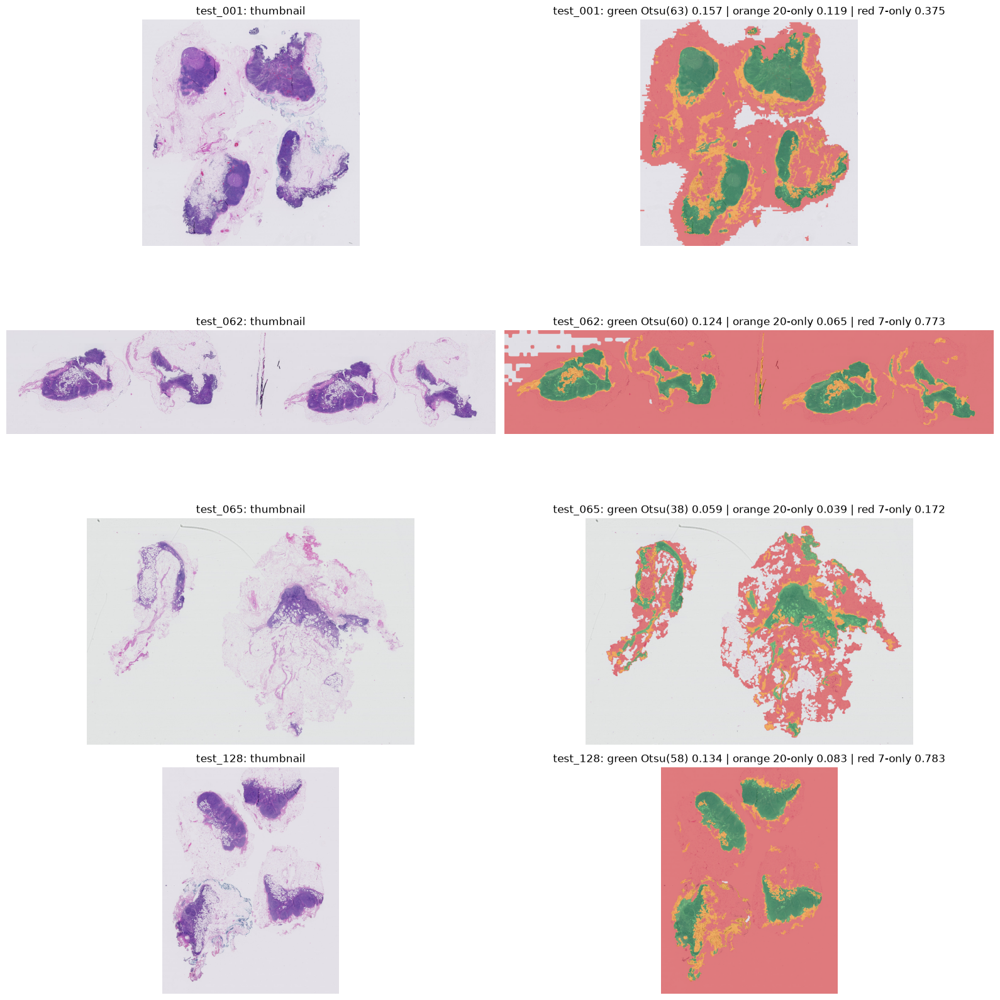

slide          @7    @20  @otsu   (tissue fraction after closing + small-object removal)
test_001    0.652  0.277  0.157
test_062    0.962  0.189  0.124
test_065    0.270  0.098  0.059
test_128    0.999  0.217  0.134


In [24]:
def slide_masks(path):
    s = openslide.OpenSlide(path)
    th = np.asarray(s.get_thumbnail(SEG_PARAMS["thumbsize"]).convert("RGB"))
    mpp = (float(s.properties[openslide.PROPERTY_NAME_MPP_X]) + float(s.properties[openslide.PROPERTY_NAME_MPP_Y])) / 2
    thumb_mpp = (mpp * (np.array(s.dimensions) / np.array([th.shape[1], th.shape[0]]))).mean()
    def seg(t):
        return _segment_tissue_from_array(
            th, median_filter_size=SEG_PARAMS["median_filter_size"], binary_threshold=t,
            closing_kernel_size=SEG_PARAMS["closing_kernel_size"],
            min_object_size_px=round(SEG_PARAMS["min_object_size_um2"] / thumb_mpp**2),
            min_hole_size_px=round(SEG_PARAMS["min_hole_size_um2"] / thumb_mpp**2))
    t_otsu = int(threshold_otsu(blurred_saturation(th)))
    return s, th, mpp, t_otsu, seg(7), seg(20), seg(t_otsu)

staged = sorted(SLIDE.parent.glob("test_*.tif"))
masks = {f.stem: slide_masks(f) for f in staged}

fig, ax = plt.subplots(len(staged), 2, figsize=(16, 4 * len(staged)))
for r, (name, (s, th, mpp, t_otsu, m7, m20, mo)) in enumerate(masks.items()):
    over = th.copy().astype(np.float32)
    colour = np.zeros_like(over)
    colour[m7 & ~m20] = (220, 40, 40)      # red: only at 7
    colour[m20 & ~mo] = (255, 150, 0)      # orange: 20 but not Otsu
    colour[mo] = (40, 180, 60)             # green: Otsu
    tinted = np.where(colour.any(-1, keepdims=True), 0.45 * over + 0.55 * colour, over).astype(np.uint8)
    ax[r, 0].imshow(th); ax[r, 0].set_title(f"{name}: thumbnail")
    ax[r, 1].imshow(tinted)
    ax[r, 1].set_title(f"{name}: green Otsu({t_otsu}) {mo.mean():.3f} | orange 20-only {(m20 & ~mo).mean():.3f} | red 7-only {(m7 & ~m20).mean():.3f}")
    for a_ in ax[r]: a_.axis("off")
plt.tight_layout(); plt.show()

print(f"{'slide':10s} {'@7':>6s} {'@20':>6s} {'@otsu':>6s}   (tissue fraction after closing + small-object removal)")
for name, (s, th, mpp, t_otsu, m7, m20, mo) in masks.items():
    print(f"{name:10s} {m7.mean():6.3f} {m20.mean():6.3f} {mo.mean():6.3f}")

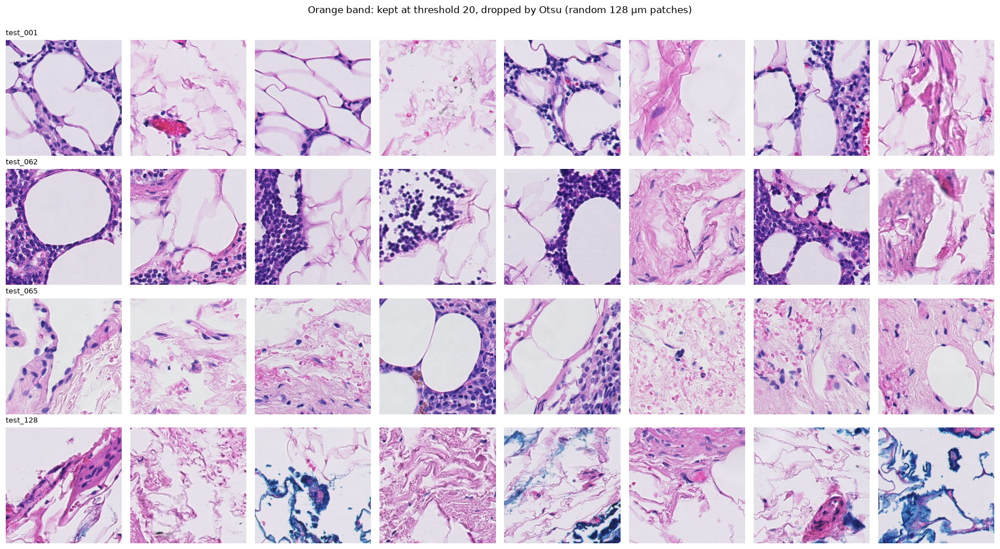

In [25]:
# Random 128 um patches whose centre falls in the orange band (kept at 20, dropped by Otsu).
rng = np.random.default_rng(1)
PER_SLIDE = 8
fig, ax = plt.subplots(len(masks), PER_SLIDE, figsize=(2.2 * PER_SLIDE, 2.4 * len(masks)))
for r, (name, (s, th, mpp, t_otsu, m7, m20, mo)) in enumerate(masks.items()):
    band = np.argwhere(m20 & ~mo)  # (row, col) in thumbnail pixels
    scale_x = s.dimensions[0] / th.shape[1]
    scale_y = s.dimensions[1] / th.shape[0]
    patch_px = round(mil.config.patch_size_um / mpp)
    pick = band[rng.choice(len(band), size=min(PER_SLIDE, len(band)), replace=False)] if len(band) else []
    for k in range(PER_SLIDE):
        ax[r, k].axis("off")
        if k >= len(pick):
            continue
        row, col = pick[k]
        x = int(col * scale_x) - patch_px // 2
        y = int(row * scale_y) - patch_px // 2
        im = s.read_region((max(x, 0), max(y, 0)), 0, (patch_px, patch_px)).convert("RGB").resize((256, 256))
        ax[r, k].imshow(im)
        ax[r, k].set_title(name if k == 0 else "", fontsize=9, loc="left")
plt.suptitle("Orange band: kept at threshold 20, dropped by Otsu (random 128 µm patches)", y=1.0)
plt.tight_layout(); plt.show()

## 14. Summary for `docs/spike-findings.md`

In [26]:
summary = {
    "slide": SLIDE.name,
    "size_mib": round(SLIDE.stat().st_size / 2**20),
    "dimensions": oslide.dimensions,
    "mpp": round(MPP, 5),
    "patch_px": PATCH_PX,
    "patches": int(N),
    "tissue_fraction": round(float(tissue_fraction), 3),
    "tissue_area_mm2": round(float(tissue_area_mm2), 1),
    "segment_s": round(timings["segment"], 2),
    "patch_s": round(timings["patch"], 2),
    "features_s": round(timings["features"], 1),
    "mil_ms_cpu": round(timings["mil"] * 1000),
    "total_s_pipeline": round(total_time, 1),
    "peak_gpu_gib_torch": round(peak_total, 2),
    "prob_metastasis": round(float(probs[0, 1]), 6),
    "otsu_threshold": otsu_t,
    "otsu_tissue_fraction": round(float(otsu_mask.mean()), 3),
    "otsu_patches": int(len(otsu_coords)),
    "otsu_prob_metastasis": round(float(p_otsu[1]), 6),
    "fixed20_tissue_fraction": round(float(mask20.mean()), 3),
    "fixed20_tissue_area_mm2": round(float(area20_mm2), 1),
    "fixed20_patches": int(len(coords20)),
    "fixed20_prob_metastasis": round(float(p_20[1]), 6),
    "attention_shape": list(attention.shape),
    "attention_min_max": [float(a.min()), float(a.max())],
    "throughput_by_workers": {k: round(v) for k, v in results.items()},
}
print(json.dumps(summary, indent=2))

{
  "slide": "test_062.tif",
  "size_mib": 455,
  "dimensions": [
    135168,
    28672
  ],
  "mpp": 0.22632,
  "patch_px": 566,
  "patches": 11728,
  "tissue_fraction": 0.962,
  "tissue_area_mm2": 190.9,
  "segment_s": 0.14,
  "patch_s": 0.09,
  "features_s": 23.4,
  "mil_ms_cpu": 39,
  "total_s_pipeline": 23.4,
  "peak_gpu_gib_torch": 0.8,
  "prob_metastasis": 0.162904,
  "otsu_threshold": 60,
  "otsu_tissue_fraction": 0.124,
  "otsu_patches": 1435,
  "otsu_prob_metastasis": 0.218303,
  "fixed20_tissue_fraction": 0.189,
  "fixed20_tissue_area_mm2": 37.5,
  "fixed20_patches": 2226,
  "fixed20_prob_metastasis": 0.134893,
  "attention_shape": [
    11728,
    1
  ],
  "attention_min_max": [
    -8.43262767791748,
    -1.246599555015564
  ],
  "throughput_by_workers": {
    "0": 82,
    "2": 181,
    "4": 308,
    "8": 486,
    "16": 511
  }
}
